In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "675-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# Ideal start with HWP/IMR phi values from the broadband table
hwp_phi_waves = 0.451
imr_phi_waves = 0.321

theta_pol = 0

delta_HWP = 2 * np.pi * hwp_phi_waves
offset_HWP = 0

delta_derot = 2 * np.pi * imr_phi_waves

delta_opts = 0
epsilon_opts = 0
rot_opts = 0

delta_FLC = 2 * np.pi * 0.5
rot_FLC = 0

dichroic_phi = 0
dichroic_epsilon = 0
dichroic_theta = 0

em_gain = 1.0  # Fixed ideal EM gain

past_fit = {
    "dichroic": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {"phi": delta_derot},
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol},
}

print("Ideal table start for 675 nm")
print("HWP phi waves:", hwp_phi_waves)
print("IMR phi waves:", imr_phi_waves)
print("Past Fit: ", past_fit)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)


Ideal table start for 675 nm
HWP phi waves: 0.451
IMR phi waves: 0.321
Past Fit:  {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.0169024836046474}, 'hwp': {'phi': 2.8337165735379934, 'delta_theta': 0}, 'lp': {'theta': 0}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.0}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.141592653589793, 'theta': 0, 'delta_theta': 0}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 2.0169024836046474, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properties': {'p

In [4]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.0169024836046474}, 'hwp': {'phi': 2.8337165735379934, 'delta_theta': 0}, 'lp': {'theta': 0}}
logl value: 13318.353945355677


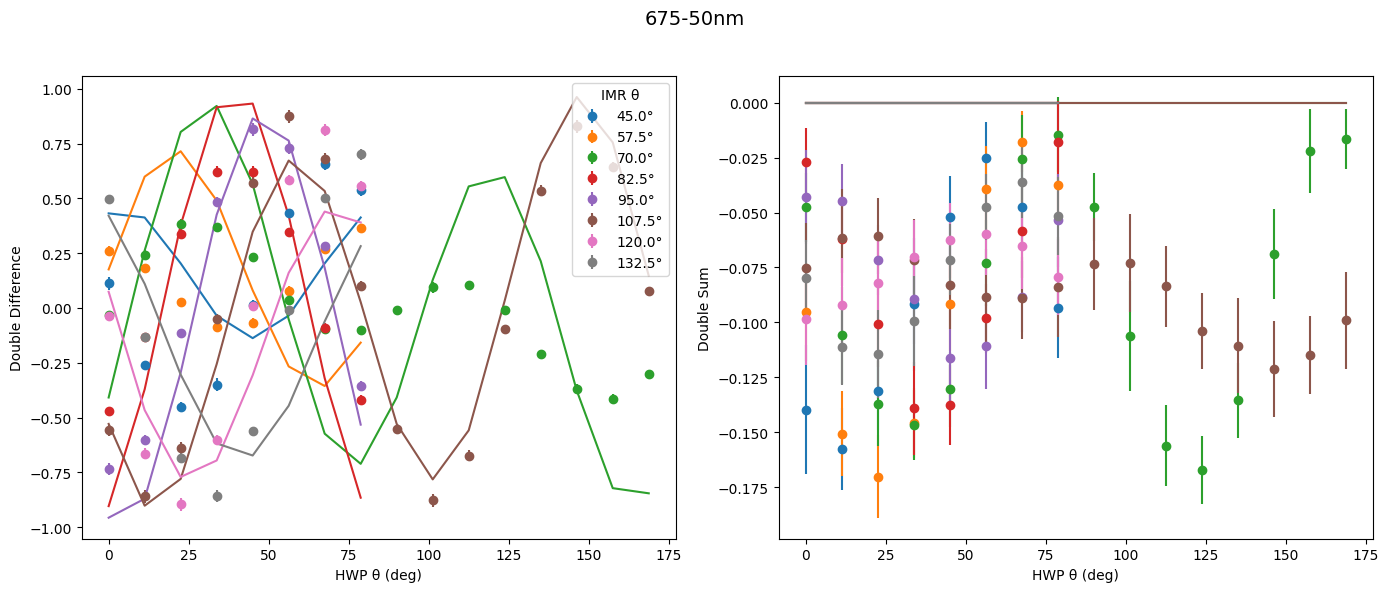

In [5]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)
p0.setdefault("image_rotator", {}).pop("delta_theta", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting initial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)


# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 2.0169024836046474}, 'hwp': {'phi': 2.8337165735379934, 'delta_theta': 0}, 'lp': {'theta': 0}}
Iteration #: 1
logl_value: 910.3214264431202
Best Fit Parameters: [ 3.40722246e+00  8.43866513e-02  8.53252531e-01  3.20555914e+00
  4.99867082e+00 -2.60408822e+00  6.25680588e-03  1.40679492e+01
  1.85234713e+00  2.90253178e+00 -1.23011257e+00 -1.53757588e+00]


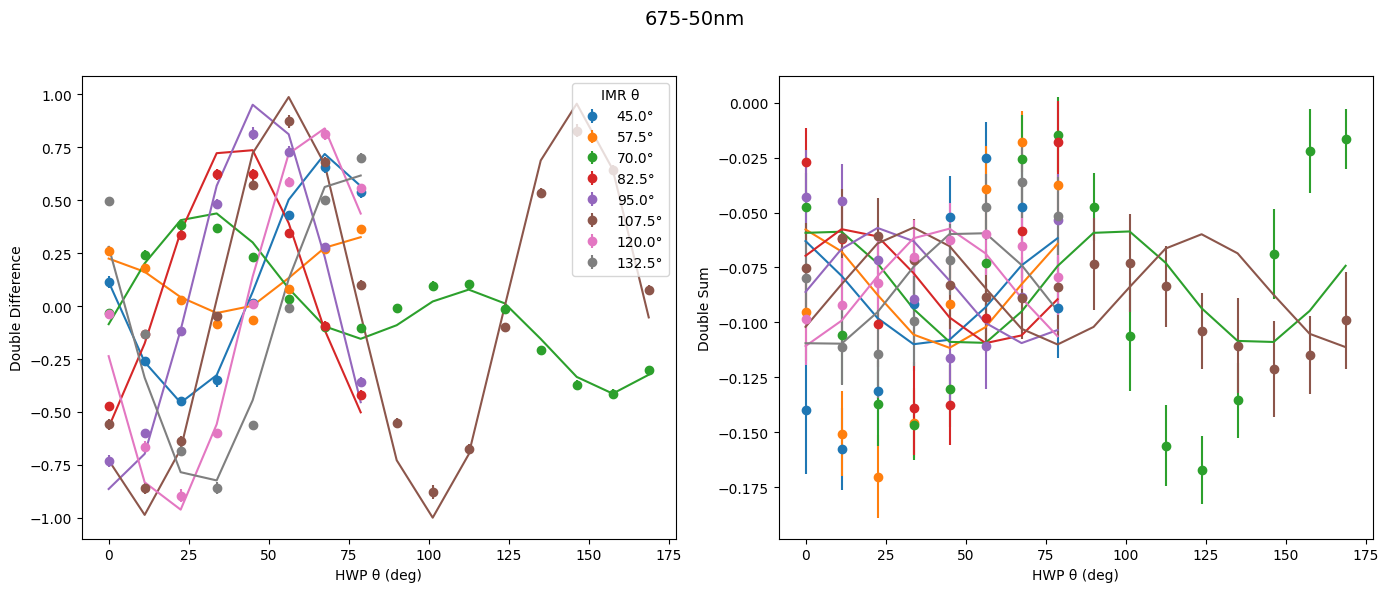

After p0: {'dichroic': {'phi': 3.407222456753386, 'epsilon': 0.0843866513334986, 'theta': 0.8532525310599774}, 'flc': {'phi': 3.205559143153473, 'delta_theta': 4.998670817380498}, 'optics': {'phi': -2.604088219450831, 'epsilon': 0.006256805879669482, 'theta': 14.067949193715627}, 'image_rotator': {'phi': 1.852347131164306}, 'hwp': {'phi': 2.9025317771304504, 'delta_theta': -1.2301125667941761}, 'lp': {'theta': -1.5375758760323905}}
Before p0: {'dichroic': {'phi': 3.407222456753386, 'epsilon': 0.0843866513334986, 'theta': 0.8532525310599774}, 'flc': {'phi': 3.205559143153473, 'delta_theta': 4.998670817380498}, 'optics': {'phi': -2.604088219450831, 'epsilon': 0.006256805879669482, 'theta': 14.067949193715627}, 'image_rotator': {'phi': 1.852347131164306}, 'hwp': {'phi': 2.9025317771304504, 'delta_theta': -1.2301125667941761}, 'lp': {'theta': -1.5375758760323905}}
Iteration #: 2
logl_value: 284.8780065033632
Best Fit Parameters: [ 3.37478617e-01  9.13557794e-02  8.09920728e+00  3.07951624e

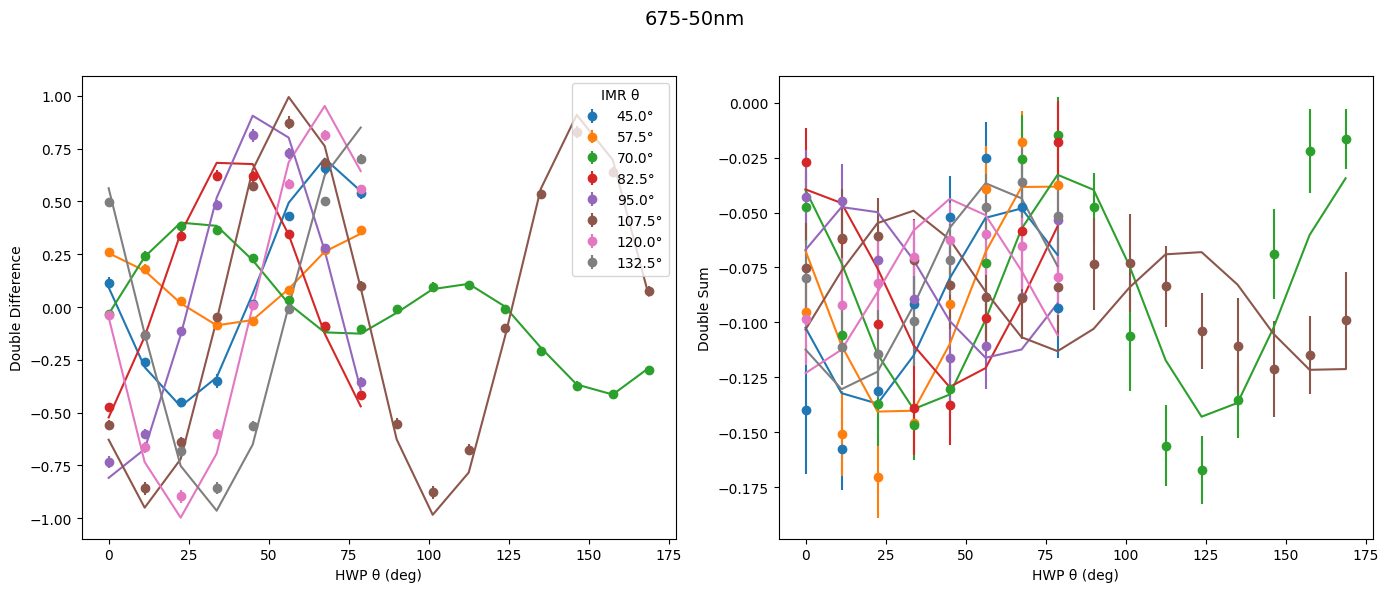

After p0: {'dichroic': {'phi': 0.33747861706996507, 'epsilon': 0.09135577944390252, 'theta': 8.099207280442709}, 'flc': {'phi': 3.079516236587574, 'delta_theta': 4.937902540454765}, 'optics': {'phi': -1.555748878069445, 'epsilon': 0.007925333254048001, 'theta': 18.739178075962243}, 'image_rotator': {'phi': 2.0953308354424793}, 'hwp': {'phi': 2.9252051719028804, 'delta_theta': 0.03573426914682489}, 'lp': {'theta': 0.4611460789736368}}
Before p0: {'dichroic': {'phi': 0.33747861706996507, 'epsilon': 0.09135577944390252, 'theta': 8.099207280442709}, 'flc': {'phi': 3.079516236587574, 'delta_theta': 4.937902540454765}, 'optics': {'phi': -1.555748878069445, 'epsilon': 0.007925333254048001, 'theta': 18.739178075962243}, 'image_rotator': {'phi': 2.0953308354424793}, 'hwp': {'phi': 2.9252051719028804, 'delta_theta': 0.03573426914682489}, 'lp': {'theta': 0.4611460789736368}}
Iteration #: 3
logl_value: 126.96662085280246
Best Fit Parameters: [ 1.58199755e-01  4.20087646e-01  3.93317525e+01  2.9946

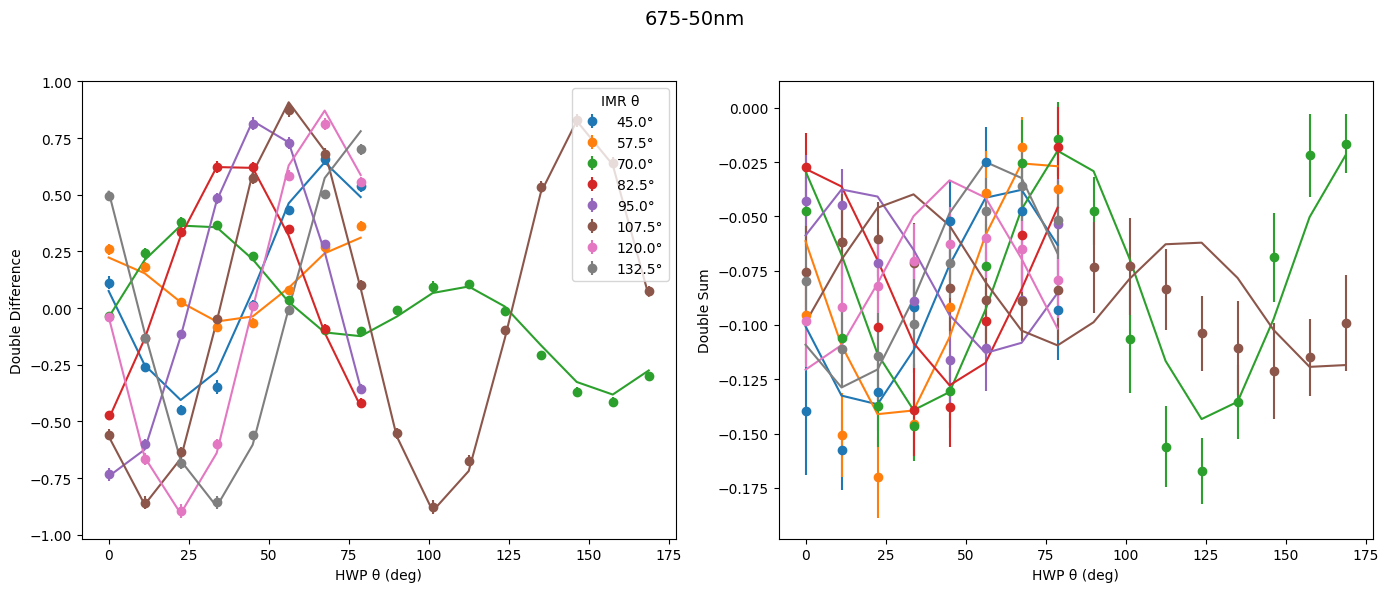

After p0: {'dichroic': {'phi': 0.15819975510499495, 'epsilon': 0.4200876462939751, 'theta': 39.33175253171032}, 'flc': {'phi': 2.9946072995470328, 'delta_theta': 4.789015029233088}, 'optics': {'phi': -1.4191824596149658, 'epsilon': 0.006881945844269311, 'theta': 18.625737047196566}, 'image_rotator': {'phi': 2.095625706235369}, 'hwp': {'phi': 2.9206441744293414, 'delta_theta': 0.13308780387531474}, 'lp': {'theta': 0.33669469485649123}}
Before p0: {'dichroic': {'phi': 0.15819975510499495, 'epsilon': 0.4200876462939751, 'theta': 39.33175253171032}, 'flc': {'phi': 2.9946072995470328, 'delta_theta': 4.789015029233088}, 'optics': {'phi': -1.4191824596149658, 'epsilon': 0.006881945844269311, 'theta': 18.625737047196566}, 'image_rotator': {'phi': 2.095625706235369}, 'hwp': {'phi': 2.9206441744293414, 'delta_theta': 0.13308780387531474}, 'lp': {'theta': 0.33669469485649123}}
Iteration #: 4
logl_value: 92.85157868467053
Best Fit Parameters: [ 1.03712350e-01  4.54247858e-01  3.95634746e+01  3.079

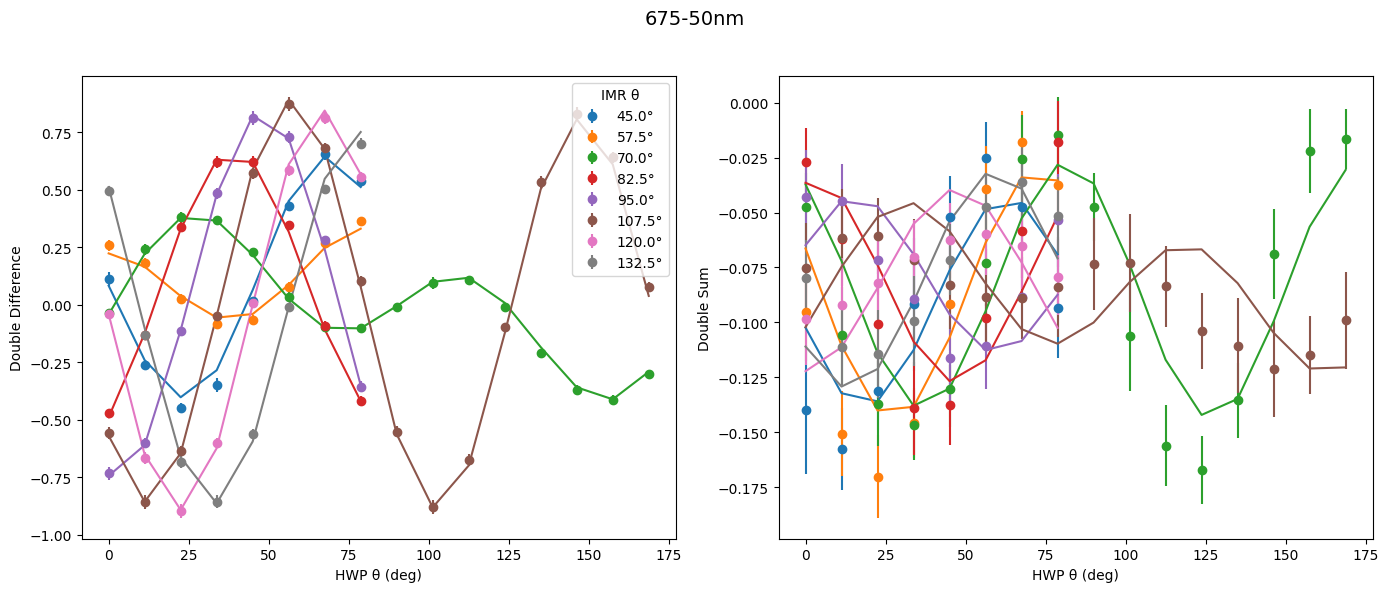

After p0: {'dichroic': {'phi': 0.10371235025399567, 'epsilon': 0.45424785808181906, 'theta': 39.56347461880477}, 'flc': {'phi': 3.0794888381394627, 'delta_theta': 4.959222963768892}, 'optics': {'phi': -1.5312665225745445, 'epsilon': 0.004746550772538777, 'theta': 18.493172140579162}, 'image_rotator': {'phi': 2.109608386006675}, 'hwp': {'phi': 2.9022138074234305, 'delta_theta': 2.450692161052007}, 'lp': {'theta': 4.998852413184677}}
Before p0: {'dichroic': {'phi': 0.10371235025399567, 'epsilon': 0.45424785808181906, 'theta': 39.56347461880477}, 'flc': {'phi': 3.0794888381394627, 'delta_theta': 4.959222963768892}, 'optics': {'phi': -1.5312665225745445, 'epsilon': 0.004746550772538777, 'theta': 18.493172140579162}, 'image_rotator': {'phi': 2.109608386006675}, 'hwp': {'phi': 2.9022138074234305, 'delta_theta': 2.450692161052007}, 'lp': {'theta': 4.998852413184677}}
Iteration #: 5
logl_value: 91.50676356193843
Best Fit Parameters: [ 1.06345632e-01  4.54300516e-01  3.95559097e+01  3.07655140e

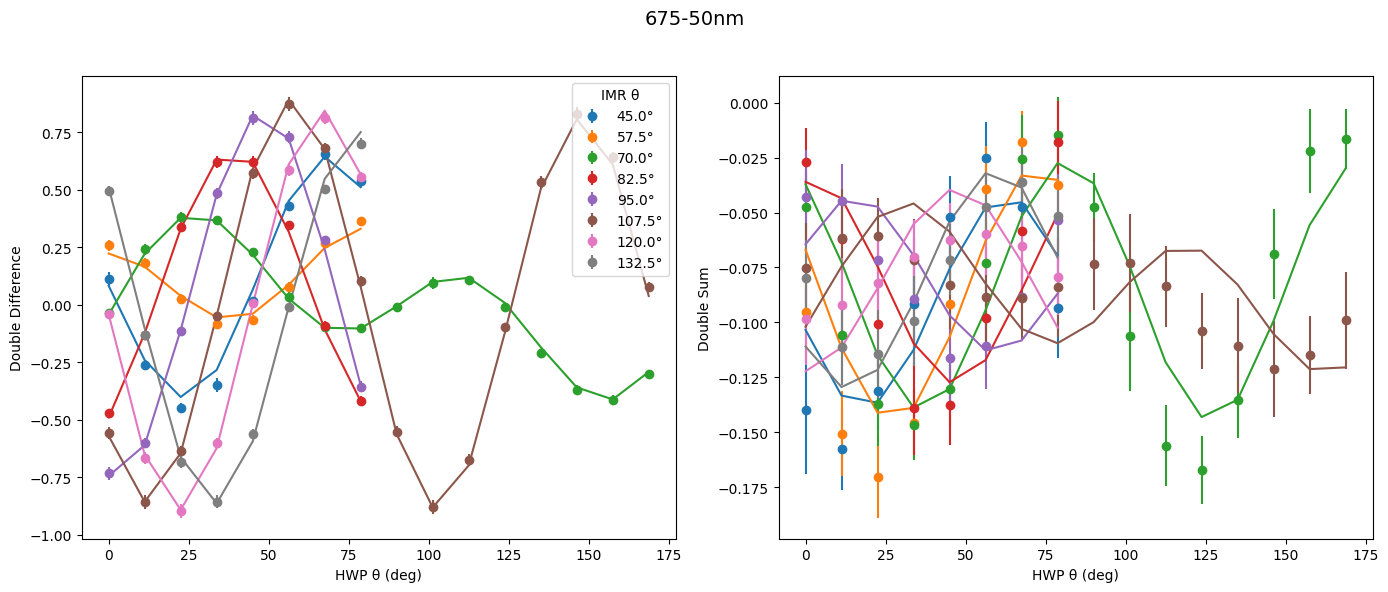

After p0: {'dichroic': {'phi': 0.10634563226951538, 'epsilon': 0.45430051601299004, 'theta': 39.55590968235529}, 'flc': {'phi': 3.076551400335326, 'delta_theta': 4.999916527747569}, 'optics': {'phi': -1.5168962014411767, 'epsilon': 0.00472330697001673, 'theta': 18.56646906283511}, 'image_rotator': {'phi': 2.1092347104262945}, 'hwp': {'phi': 2.9017341204974016, 'delta_theta': 2.464516259172134}, 'lp': {'theta': 4.998979745972832}}
Before p0: {'dichroic': {'phi': 0.10634563226951538, 'epsilon': 0.45430051601299004, 'theta': 39.55590968235529}, 'flc': {'phi': 3.076551400335326, 'delta_theta': 4.999916527747569}, 'optics': {'phi': -1.5168962014411767, 'epsilon': 0.00472330697001673, 'theta': 18.56646906283511}, 'image_rotator': {'phi': 2.1092347104262945}, 'hwp': {'phi': 2.9017341204974016, 'delta_theta': 2.464516259172134}, 'lp': {'theta': 4.998979745972832}}
Iteration #: 6
logl_value: 91.49198873776525
Best Fit Parameters: [ 1.05120247e-01  4.54381334e-01  3.95584704e+01  3.07843899e+00


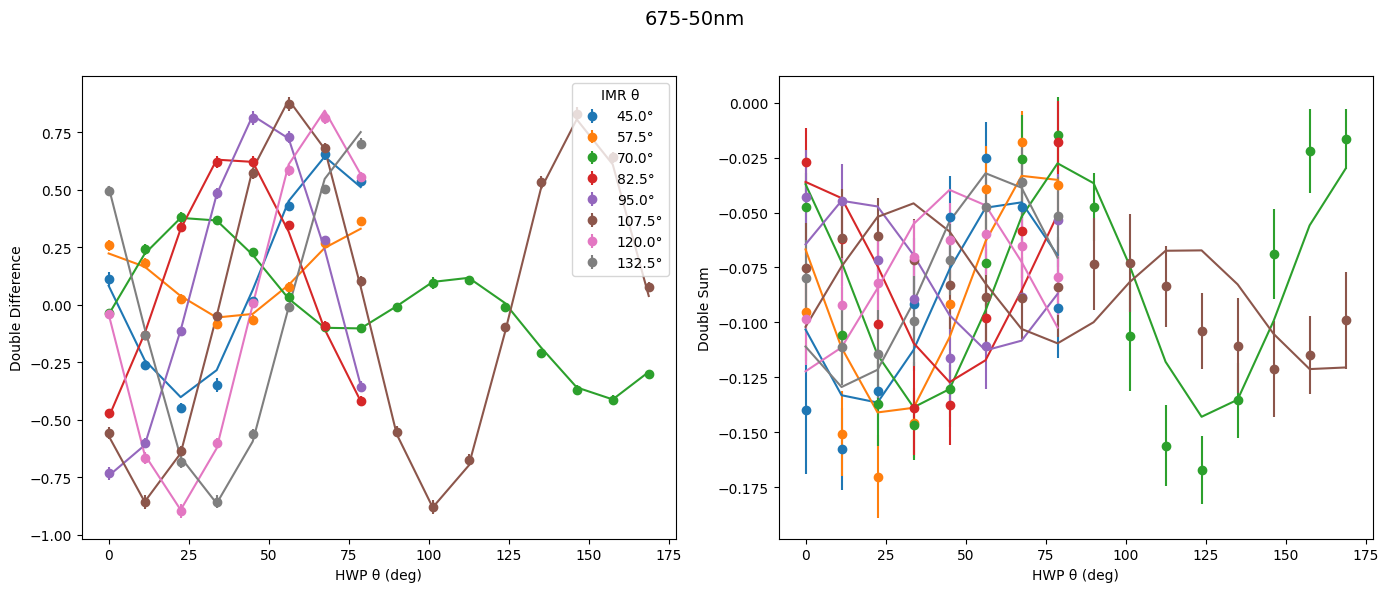

After p0: {'dichroic': {'phi': 0.1051202465612838, 'epsilon': 0.45438133404828696, 'theta': 39.558470380670755}, 'flc': {'phi': 3.0784389861117076, 'delta_theta': 4.999984749089137}, 'optics': {'phi': -1.520959093640227, 'epsilon': 0.004930552875191086, 'theta': 18.5675828168117}, 'image_rotator': {'phi': 2.1094554021905463}, 'hwp': {'phi': 2.9017787889940676, 'delta_theta': 2.454596571437552}, 'lp': {'theta': 4.9999970373664}}
Before p0: {'dichroic': {'phi': 0.1051202465612838, 'epsilon': 0.45438133404828696, 'theta': 39.558470380670755}, 'flc': {'phi': 3.0784389861117076, 'delta_theta': 4.999984749089137}, 'optics': {'phi': -1.520959093640227, 'epsilon': 0.004930552875191086, 'theta': 18.5675828168117}, 'image_rotator': {'phi': 2.1094554021905463}, 'hwp': {'phi': 2.9017787889940676, 'delta_theta': 2.454596571437552}, 'lp': {'theta': 4.9999970373664}}
Iteration #: 7
logl_value: 91.49103586732097
Best Fit Parameters: [ 1.05170313e-01  4.54258637e-01  3.95563698e+01  3.07833192e+00
  5.

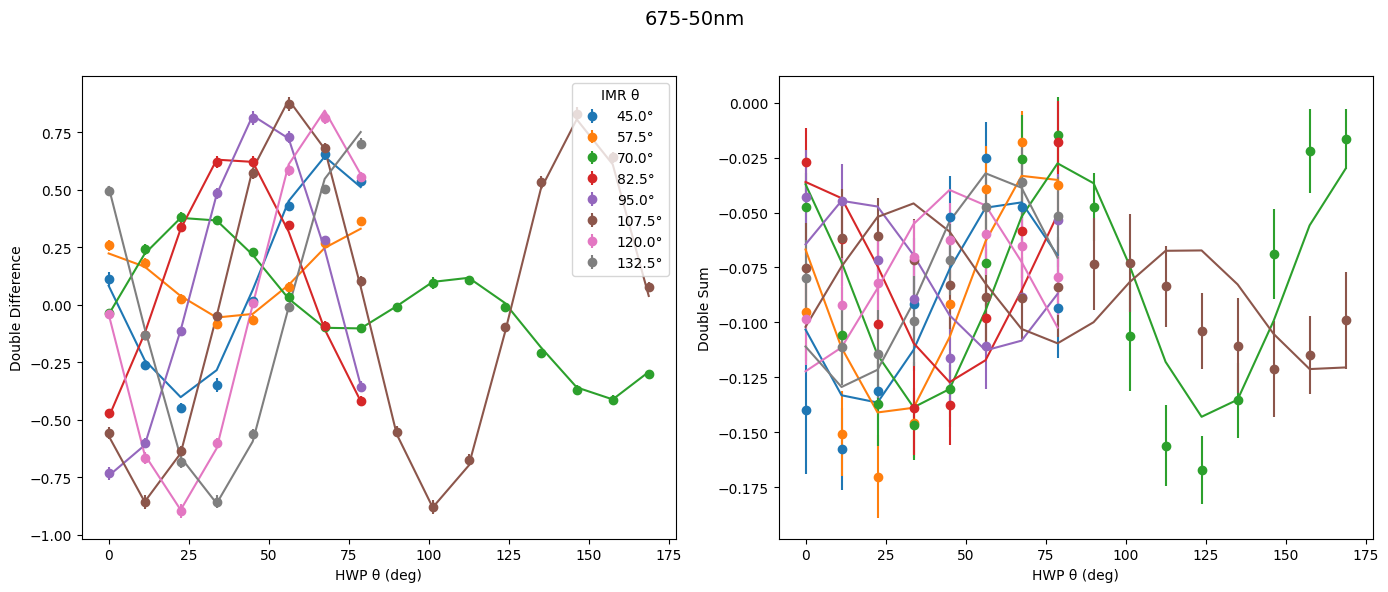

After p0: {'dichroic': {'phi': 0.10517031286544579, 'epsilon': 0.4542586365744855, 'theta': 39.55636981262805}, 'flc': {'phi': 3.0783319193542225, 'delta_theta': 5.0}, 'optics': {'phi': -1.5204119762839539, 'epsilon': 0.004876995081047901, 'theta': 18.571536257585493}, 'image_rotator': {'phi': 2.109598570051835}, 'hwp': {'phi': 2.90186346516873, 'delta_theta': 2.454942863308458}, 'lp': {'theta': 4.999991335190936}}
Before p0: {'dichroic': {'phi': 0.10517031286544579, 'epsilon': 0.4542586365744855, 'theta': 39.55636981262805}, 'flc': {'phi': 3.0783319193542225, 'delta_theta': 5.0}, 'optics': {'phi': -1.5204119762839539, 'epsilon': 0.004876995081047901, 'theta': 18.571536257585493}, 'image_rotator': {'phi': 2.109598570051835}, 'hwp': {'phi': 2.90186346516873, 'delta_theta': 2.454942863308458}, 'lp': {'theta': 4.999991335190936}}
Iteration #: 8
logl_value: 91.49103146085645
Best Fit Parameters: [ 1.05151967e-01  4.54259695e-01  3.95563619e+01  3.07836154e+00
  5.00000000e+00 -1.52050419e+

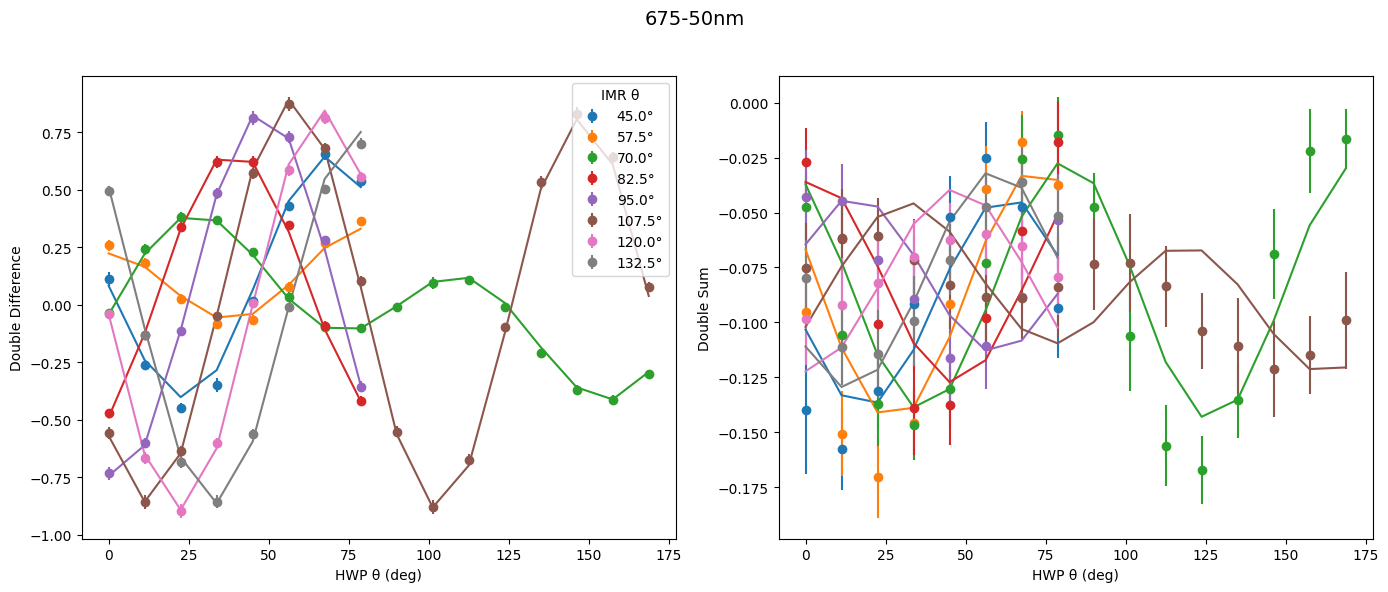

After p0: {'dichroic': {'phi': 0.10515196653078465, 'epsilon': 0.4542596948440892, 'theta': 39.5563619238292}, 'flc': {'phi': 3.0783615371066864, 'delta_theta': 4.999999996067315}, 'optics': {'phi': -1.520504188600353, 'epsilon': 0.004870783205043239, 'theta': 18.571095365907084}, 'image_rotator': {'phi': 2.1095818308645593}, 'hwp': {'phi': 2.901862558833427, 'delta_theta': 2.4547496637949586}, 'lp': {'theta': 4.999992332454514}}
Before p0: {'dichroic': {'phi': 0.10515196653078465, 'epsilon': 0.4542596948440892, 'theta': 39.5563619238292}, 'flc': {'phi': 3.0783615371066864, 'delta_theta': 4.999999996067315}, 'optics': {'phi': -1.520504188600353, 'epsilon': 0.004870783205043239, 'theta': 18.571095365907084}, 'image_rotator': {'phi': 2.1095818308645593}, 'hwp': {'phi': 2.901862558833427, 'delta_theta': 2.4547496637949586}, 'lp': {'theta': 4.999992332454514}}
Iteration #: 9
logl_value: 91.49102896397834
Best Fit Parameters: [ 1.05118821e-01  4.54250950e-01  3.95561727e+01  3.07841541e+00


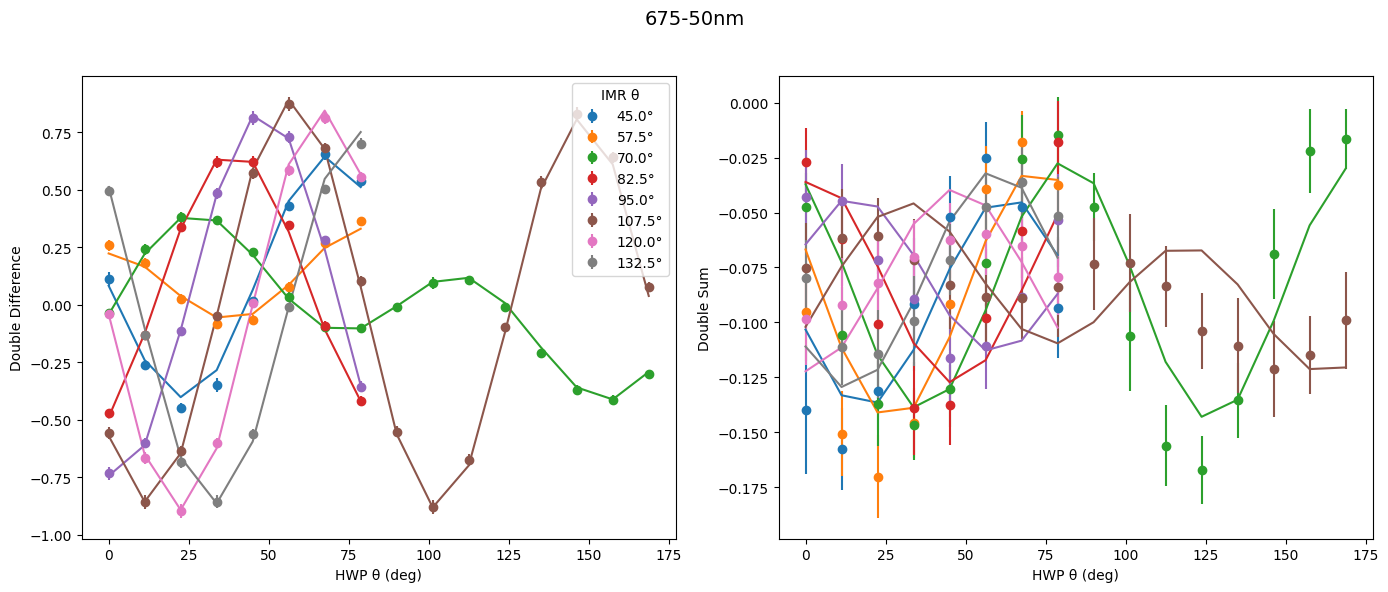

After p0: {'dichroic': {'phi': 0.10511882067321945, 'epsilon': 0.4542509502639245, 'theta': 39.55617272863937}, 'flc': {'phi': 3.07841541085277, 'delta_theta': 4.9999999968863555}, 'optics': {'phi': -1.5205665772917207, 'epsilon': 0.004873304533300167, 'theta': 18.57119743498269}, 'image_rotator': {'phi': 2.1095870246960127}, 'hwp': {'phi': 2.901859362891442, 'delta_theta': 2.4547347746498427}, 'lp': {'theta': 4.999994631026063}}
Before p0: {'dichroic': {'phi': 0.10511882067321945, 'epsilon': 0.4542509502639245, 'theta': 39.55617272863937}, 'flc': {'phi': 3.07841541085277, 'delta_theta': 4.9999999968863555}, 'optics': {'phi': -1.5205665772917207, 'epsilon': 0.004873304533300167, 'theta': 18.57119743498269}, 'image_rotator': {'phi': 2.1095870246960127}, 'hwp': {'phi': 2.901859362891442, 'delta_theta': 2.4547347746498427}, 'lp': {'theta': 4.999994631026063}}
Iteration #: 10
logl_value: 91.4910249986592
Best Fit Parameters: [ 1.05145692e-01  4.54250650e-01  3.95562182e+01  3.07837533e+00


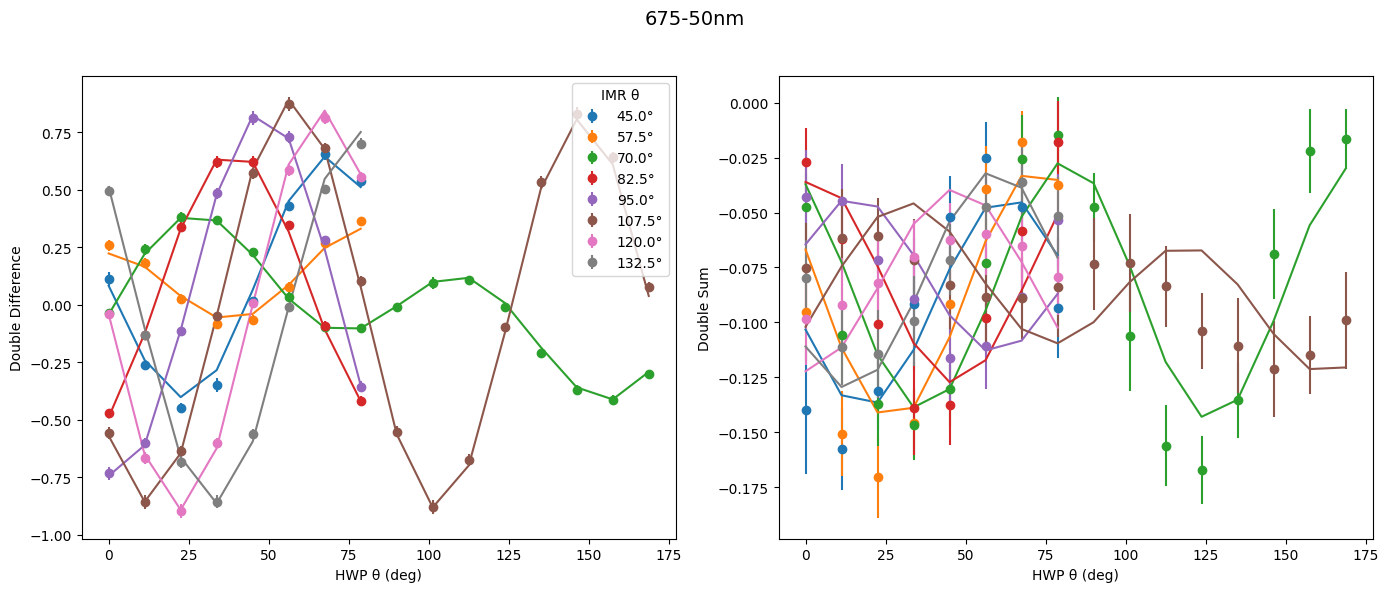

After p0: {'dichroic': {'phi': 0.10514569181795866, 'epsilon': 0.45425065040271084, 'theta': 39.55621822784573}, 'flc': {'phi': 3.078375330711086, 'delta_theta': 4.9999999775520125}, 'optics': {'phi': -1.5204990453836267, 'epsilon': 0.004874634925606431, 'theta': 18.571202509189753}, 'image_rotator': {'phi': 2.1095838616935727}, 'hwp': {'phi': 2.9018571684865897, 'delta_theta': 2.454832786174822}, 'lp': {'theta': 5.0}}
Before p0: {'dichroic': {'phi': 0.10514569181795866, 'epsilon': 0.45425065040271084, 'theta': 39.55621822784573}, 'flc': {'phi': 3.078375330711086, 'delta_theta': 4.9999999775520125}, 'optics': {'phi': -1.5204990453836267, 'epsilon': 0.004874634925606431, 'theta': 18.571202509189753}, 'image_rotator': {'phi': 2.1095838616935727}, 'hwp': {'phi': 2.9018571684865897, 'delta_theta': 2.454832786174822}, 'lp': {'theta': 5.0}}
Iteration #: 11
logl_value: 91.49102442864822
Best Fit Parameters: [ 1.05148191e-01  4.54251507e-01  3.95562288e+01  3.07836846e+00
  4.99999998e+00 -1.5

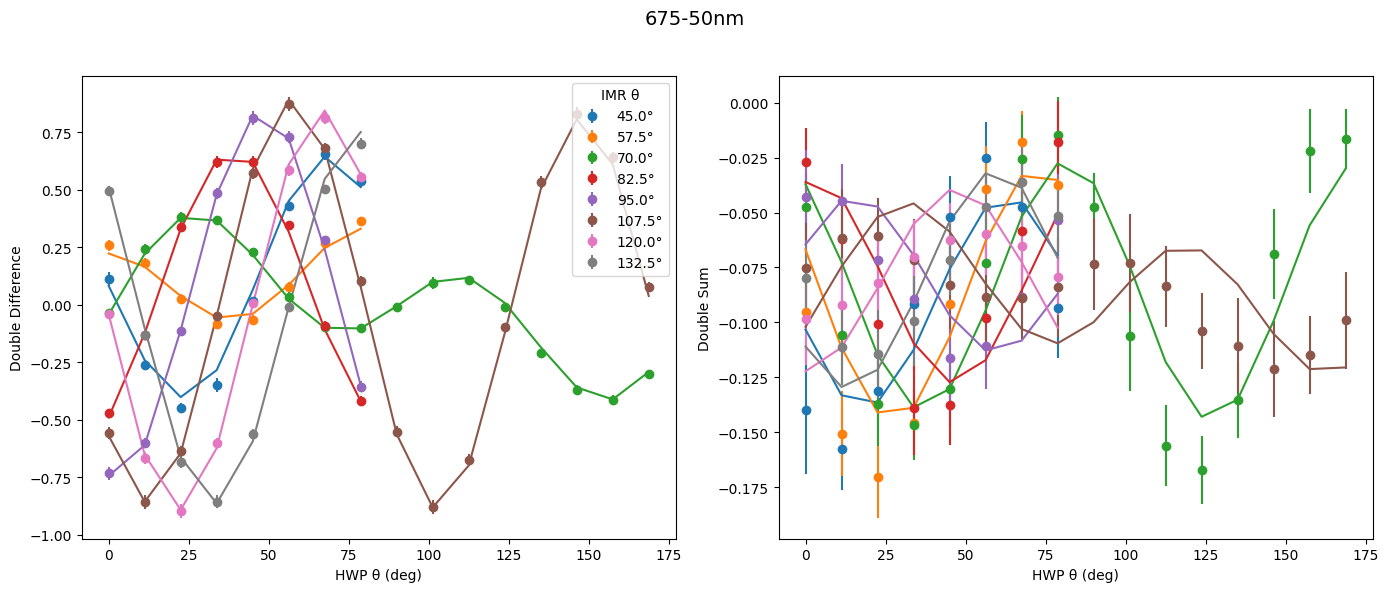

After p0: {'dichroic': {'phi': 0.10514819112399011, 'epsilon': 0.45425150653890517, 'theta': 39.55622877825844}, 'flc': {'phi': 3.0783684613301254, 'delta_theta': 4.999999984251672}, 'optics': {'phi': -1.5205213231789834, 'epsilon': 0.004874405491348446, 'theta': 18.571074226066102}, 'image_rotator': {'phi': 2.1095815400620115}, 'hwp': {'phi': 2.9018588106258774, 'delta_theta': 2.454737426123386}, 'lp': {'theta': 4.999999913963519}}
Before p0: {'dichroic': {'phi': 0.10514819112399011, 'epsilon': 0.45425150653890517, 'theta': 39.55622877825844}, 'flc': {'phi': 3.0783684613301254, 'delta_theta': 4.999999984251672}, 'optics': {'phi': -1.5205213231789834, 'epsilon': 0.004874405491348446, 'theta': 18.571074226066102}, 'image_rotator': {'phi': 2.1095815400620115}, 'hwp': {'phi': 2.9018588106258774, 'delta_theta': 2.454737426123386}, 'lp': {'theta': 4.999999913963519}}
Iteration #: 12
logl_value: 91.49102368872767
Best Fit Parameters: [ 1.05135128e-01  4.54253927e-01  3.95562508e+01  3.078389

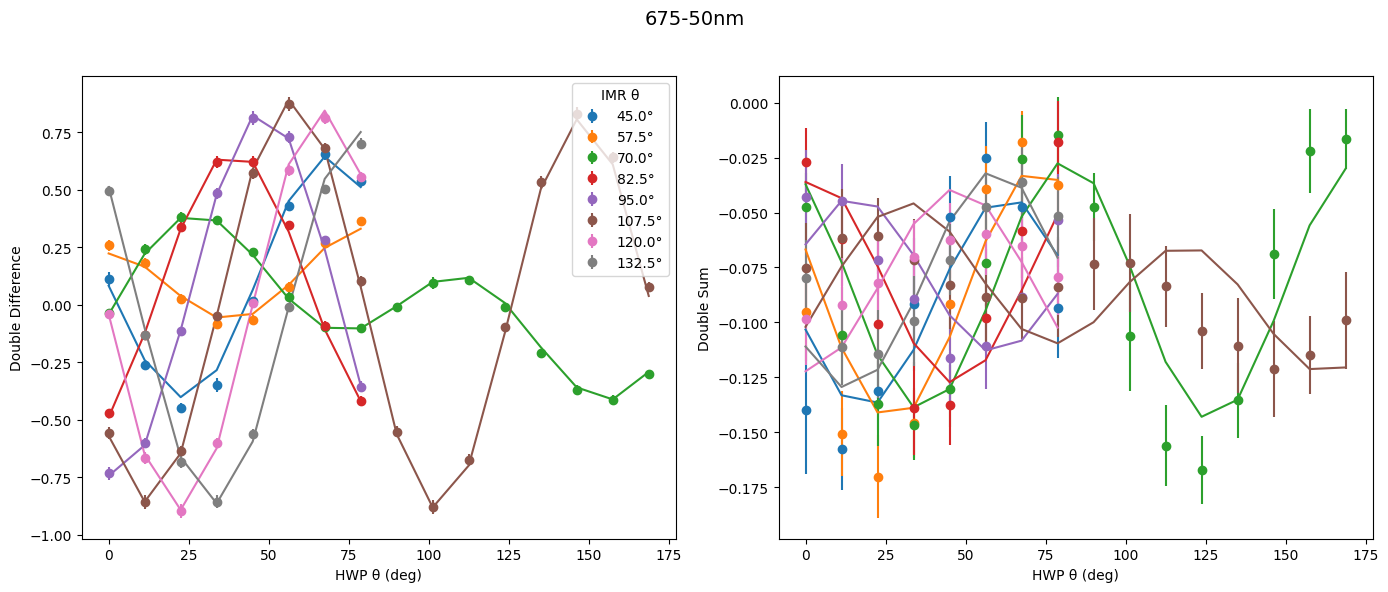

After p0: {'dichroic': {'phi': 0.1051351276225541, 'epsilon': 0.45425392728164626, 'theta': 39.55625082192344}, 'flc': {'phi': 3.078389015869318, 'delta_theta': 4.999999998900558}, 'optics': {'phi': -1.5205404349597618, 'epsilon': 0.004875648269317038, 'theta': 18.571094484747988}, 'image_rotator': {'phi': 2.109583191340963}, 'hwp': {'phi': 2.9018597517734293, 'delta_theta': 2.4547606140821667}, 'lp': {'theta': 4.999999996224716}}
Before p0: {'dichroic': {'phi': 0.1051351276225541, 'epsilon': 0.45425392728164626, 'theta': 39.55625082192344}, 'flc': {'phi': 3.078389015869318, 'delta_theta': 4.999999998900558}, 'optics': {'phi': -1.5205404349597618, 'epsilon': 0.004875648269317038, 'theta': 18.571094484747988}, 'image_rotator': {'phi': 2.109583191340963}, 'hwp': {'phi': 2.9018597517734293, 'delta_theta': 2.4547606140821667}, 'lp': {'theta': 4.999999996224716}}
Iteration #: 13
logl_value: 91.49102365447632
Best Fit Parameters: [ 1.05136694e-01  4.54252592e-01  3.95562578e+01  3.07838605e+

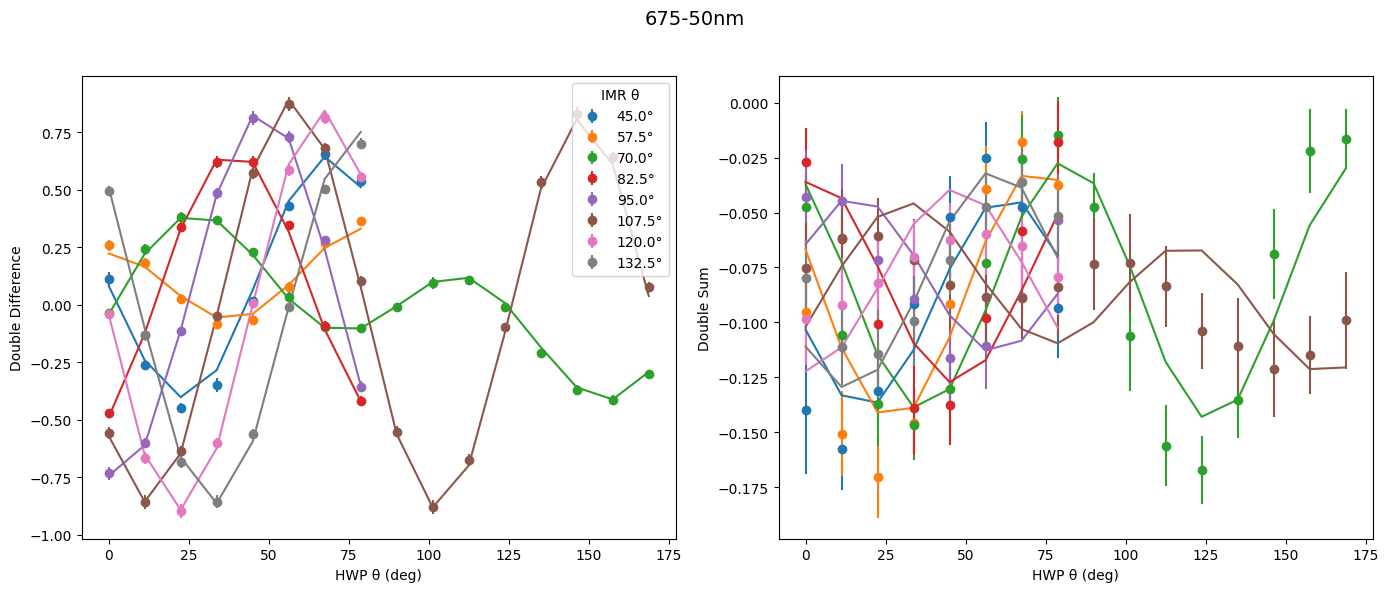

After p0: {'dichroic': {'phi': 0.1051366940108763, 'epsilon': 0.4542525923562888, 'theta': 39.55625778395081}, 'flc': {'phi': 3.0783860479340572, 'delta_theta': 4.999999999473679}, 'optics': {'phi': -1.5205319358901306, 'epsilon': 0.004874865477118963, 'theta': 18.571141761444864}, 'image_rotator': {'phi': 2.109582825093769}, 'hwp': {'phi': 2.9018593071482908, 'delta_theta': 2.4547788597893865}, 'lp': {'theta': 4.999999977406556}}
Before p0: {'dichroic': {'phi': 0.1051366940108763, 'epsilon': 0.4542525923562888, 'theta': 39.55625778395081}, 'flc': {'phi': 3.0783860479340572, 'delta_theta': 4.999999999473679}, 'optics': {'phi': -1.5205319358901306, 'epsilon': 0.004874865477118963, 'theta': 18.571141761444864}, 'image_rotator': {'phi': 2.109582825093769}, 'hwp': {'phi': 2.9018593071482908, 'delta_theta': 2.4547788597893865}, 'lp': {'theta': 4.999999977406556}}
Iteration #: 14
logl_value: 91.49102365447632
Best Fit Parameters: [ 1.05136694e-01  4.54252592e-01  3.95562578e+01  3.07838605e+

In [6]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-2 * np.pi, 2 * np.pi),  # delta_opts
    (0, 1),  # epsilon_opts
    (-90, 90),  # rot_opts
    (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),  # delta_derot
    (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

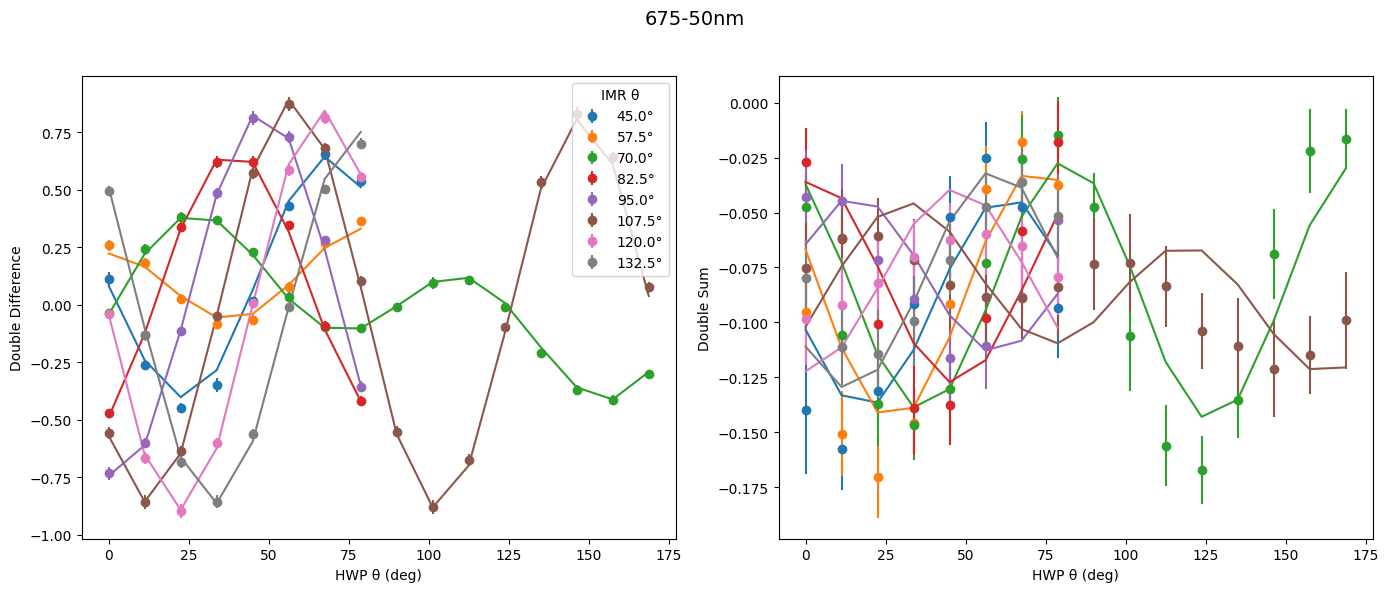

In [7]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)